In [28]:
#| echo: false
#| output: false
#| eval: true
#| warning: false
from fastai.vision.all import *
from fastai.vision.models import *
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

path_imagenette=untar_data(URLs.IMAGENETTE)
path_mnist=untar_data(URLs.MNIST_SAMPLE)
im3 = Image.open(path_mnist/'train'/'3'/'12.png')
# show_image(im3)
def get_data(url,presize,resize):
  path= untar_data(url)
  return DataBlock(
      blocks=(ImageBlock, CategoryBlock),
      get_items=get_image_files,
      splitter=GrandparentSplitter('train', 'val'),
      get_y=parent_label,
      item_tfms=Resize(presize),
      batch_tfms=[*aug_transforms(size=resize, max_warp=0), Normalize.from_stats(*imagenet_stats)]
  ).dataloaders(path, num_workers=0, pin_memory=False, persistent_workers=False,bs=128)

# Overview

In this blog post, we will explore the architecture of Convolution Neural Networks (CNN) and how they have been used to achieve state-of-the-art performance in image recognition tasks. We will also discuss some of the key components of CNNs, such as convolution layers, pooling layers, and activation functions. Finally, we will look at one of the most popular CNN architectures: `ResNet`.

Here is the environment that we applied to train the CNN model(s):

In [5]:
import os
import subprocess
import torch
def run_cmd(cmd):
    try:
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT, shell=True, text=True)
        return out.strip()
    except Exception as e:
        return f"(error running `{cmd}`: {e})"

def print_cuda_info():
    print("torch.cuda.is_available():", torch.cuda.is_available())
    print("torch.version.cuda:", torch.version.cuda)
    print("cudnn version:", torch.backends.cudnn.version() if torch.backends.cudnn.is_available() else "<cudnn not available>")
    if torch.cuda.is_available():
        print("torch.cuda.device_count():", torch.cuda.device_count())
        for i in range(torch.cuda.device_count()):
            try:
                name = torch.cuda.get_device_name(i)
            except Exception:
                name = "<unknown>"
            print(f"  GPU {i}: {name}")
        try:
            cur = torch.cuda.current_device()
            print("torch.cuda.current_device():", cur)
        except Exception:
            pass
    else:
        print("No CUDA GPUs detected by torch.")
    # print("\nnvidia-smi output (if available):")
    print(run_cmd("nvidia-smi --query-gpu=index,name,memory.total,utilization.gpu --format=csv,noheader,nounits"))


print_cuda_info()

torch.cuda.is_available(): True
torch.version.cuda: 12.4
cudnn version: 90100
torch.cuda.device_count(): 2
  GPU 0: NVIDIA A100 80GB PCIe
  GPU 1: NVIDIA A100 80GB PCIe
torch.cuda.current_device(): 0
0, NVIDIA A100 80GB PCIe, 81920, 0
1, NVIDIA A100 80GB PCIe, 81920, 0


# Overview of Convolution Neural Networks (CNN)
In the context of computer vision, **feature engineering** is the process of using domain knowledge to extract distinctive attributes from images that can be used to improve the performance of machine learning algorithms. For instance, in image classification tasks, the number 7 is characterized by a horizontal edge near the top, and a diagonal line that goes down to the right. These features can be used to distinguish the number 7 from other digits.

It turns out that finding the edges in an image is a crucial step in computer vision tasks. To achieve this, we can use a technique called **convolution**. Convolution is a mathematical operation that takes two inputs: an image and a filter (also known as a kernel). The filter is a small matrix that is used to scan the image and extract features. For example, the following filter can be used to detect horizontal edges in an image. 

## Convolution Layer
A convolution layer applies a set of filters (i.e., **kernel**) to the input image to extract features. Each filter/kernel is a small matrix that is used to scan the image and extract features. The output of a convolution layer is a set of feature maps, which are the result of applying each filter to the input image.

![An example of kernel](./imgs/kernel.png){#fig-kernel fig-align="center"}

As illustrated in Figure @fig-kernel, a 3x3 matrix kernel is applied to the input image, which is 7x7 grid. The kernel is applied to each pixel in the image, and the output is a new pixel value that is calculated by taking the dot product of the kernel and the corresponding pixels in the image. This process is repeated for each pixel in the image, resulting in a new feature map.

Let's take another look at how convolution works in practice. We will use the `im3` image, which is a 28x28 grayscale image of the digit 3 from the MNIST dataset. We will apply a 3x3 kernel to the image to extract features.

In [6]:
#| echo: false
#| output: true
#| eval: true
#| warning: false

im3_t=tensor(im3)
df = pd.DataFrame(im3_t[:10,:30])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,12,99,91,142,155,246,182,155,155,155,155,131,52,0,0,0,0,0,0,0,0,0,0,0,0
6,0,0,0,138,254,254,254,254,254,254,254,254,254,254,254,252,210,122,33,0,0,0,0,0,0,0,0,0
7,0,0,0,220,254,254,254,235,189,189,189,189,150,189,205,254,254,254,75,0,0,0,0,0,0,0,0,0
8,0,0,0,35,74,35,35,25,0,0,0,0,0,0,13,224,254,254,153,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,90,254,254,247,53,0,0,0,0,0,0,0,0,0


Let's define a kernel that detects horizontal edges in the image. The kernel is a 3x3 matrix with values that are designed to highlight horizontal edges.

In [6]:
kernel = tensor([[-1., -1., -1.],
                 [ 0.,  0.,  0.],
                 [ 1.,  1.,  1.]]).float()

This kernel will detect horizontal edges in the image by emphasizing the differences between the pixel values in the top and bottom rows of the kernel, we can also change the kernel to have the row of 1s at the top and -1s at the bottom, we can detect horizontal edges that go from dark to light, putting 1s and -1s in columns versus rows give us filters that detect vertical edges.  

In [7]:
def apply_kernel(row, col, kernel):
    return (im3_t[row-1:row+2,col-1:col+2] * kernel).sum()

For a more in-depth guide to convolution arithmetic, see the paper [A guide to convolution arithmetic for deep learning](https://arxiv.org/abs/1603.07285) (Dumoulin, 2013)^[Dumoulin, V. (2016). "A guide to convolution arithmetic for deep learning".].


## Strides and Padding
With convolution arithmetic, the kernel is applied to each pixel in the image, resulting in a new feature map that the dimensions are smaller than the original image. This is because the kernel cannot be applied to the pixels at the edges of the image. To address this issue, we can use two techniques: **strides** and **padding**.

**Strides** refer to the number of pixels by which we move the kernel across the image. By default, the stride is set to 1, meaning we move the kernel one pixel at a time. However, we can increase the stride to reduce the size of the output feature map. For example, if we set the stride to 2, the kernel will move two pixels at a time, resulting in a smaller output feature map.

**Padding** involves adding extra pixels around the edges of the image before applying the kernel. This allows us to preserve the spatial dimensions of the input image in the output feature map. There are different types of padding, such as zero-padding (adding zeros) and reflection padding (adding a mirror image of the border pixels).

![An example of padding with stride of 2](./imgs/padding.png){#fig-padding fig-align="center"}

As illustrated in @fig-padding, a 5x5 input image is padded with a 2-pixel border of zeros, resulting in a 7x7 padded image. A 4x4 kernel is then applied to the padded image with a stride of 1, resulting in a 5x5 output feature map.


In general, if we add a kernel of size $ks \times ks$ ($ks$ is an odd number) to an input image of size $n \times n$, the neccessary padding $p$ to preserve the spatial dimensions of the input image in the output feature map is given by:
$$
p = ks//2
$$
When $ks$ is even, we can use asymmetric padding, for example, if $ks=4$, we can use $p=(ks//2, ks//2-1)$. 

Furthermore, if we apply the kernel with a stride of $s$, the output feature map will have dimensions:
$$
\text{output size} = (n + 2p - ks)//(s) + 1
$$

## Create a Convolution Layer with PyTorch
We can create a convolution layer using PyTorch's `nn.Conv2d` class. The `nn.Conv2d` class takes several parameters, including the number of input channels, the number of output channels, the kernel size, the stride, and the padding.

In [8]:
#| echo: false
#| output: true
#| eval: true
#| warning: false

cnn = sequential(
    nn.Conv2d(1, 30, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.Conv2d(30, 1, kernel_size=3, stride=1, padding=1)
)

In this example, we create a convolution layer with 1 input channel (grayscale image), 30 output channels (feature maps), a kernel size of 3x3, a stride of 1, and padding of 1. We also apply the ReLU activation function after the first convolution layer.
One interesting property to note here is that we do not need to specify the input size when creating the convolution layer because a convolution is applied over each pixel automatically.

In [16]:
#| echo: false
#| output: false
#| eval: true
#| warning: false

mnist = DataBlock(
    blocks=(ImageBlock(cls=PILImageBW), CategoryBlock),
    get_items=get_image_files,
    splitter=GrandparentSplitter(),
    get_y=parent_label,
    # item_tfms=Resize(28),
    # batch_tfms=Normalize()
)

dls = mnist.dataloaders(path_mnist)
# dls = dls.new(num_workers=0, persistent_workers=False)
xb,yb = first(dls.valid) 

When creating `cnn` as above, we see that the output shape is the same as the input shape, which is (28, 28) (This is because we have used padding to preserve the spatial dimensions of the input image in the output feature map). It is not interesting for classification task since we need only single output activation per input image. 

To deal with this, we can use several stride-2 convolution layers to reduce the spatial dimensions of the input image in the output feature map. For example, we can use two stride-2 convolution layers to reduce the spatial dimensions of the input image from (28, 28) to (7, 7), (4x4), (2x2) and then 1.

In [10]:
def conv(ni, nf, ks=3, act=True):
    res = nn.Conv2d(ni, nf, stride=2, kernel_size=ks, padding=ks//2)
    if act: res = nn.Sequential(res, nn.ReLU()) 
    return res

Then, we create a simple `cnn` which consists of several convolution layers with stride of 2, kernel size of 3 to reduce the spatial dimensions of the input image in the output feature map. We also flatten the output feature map before passing it to the final classification layer.:

In [11]:
simple_cnn = sequential(
    conv(1, 4),   # Input: 28x28 -> Output: 14x14
    conv(4, 8),  # Input: 14x14 -> Output: 7x7
    conv(8, 16), # Input: 7x7 -> Output: 4x4
    conv(16, 32), # Input: 4x4 -> Output: 2x2
    conv(32, 2, act=False), # Input: 2x2 -> Output: 1x1
    Flatten()
)

SuggestedLRs(valley=0.007585775572806597)

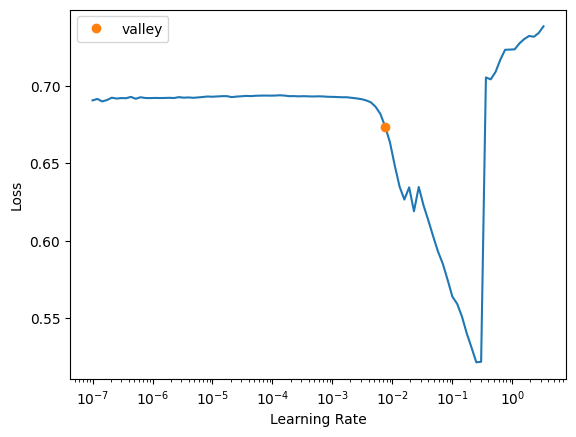

To test our `simple_cnn`, we can train a classification model from a batch of images from the MNIST dataset to see how effective of the feature extraction it is. To do this, we build a `Learner` from `simple_cnn` and dataset `dls` as follows:

In [12]:
learn = Learner(dls, simple_cnn, loss_func=F.cross_entropy, metrics=accuracy)
learn.summary()

Sequential (Input shape: 64 x 1 x 28 x 28)
Layer (type)         Output Shape         Param #    Trainable 
                     64 x 4 x 14 x 14    
Conv2d                                    40         True      
ReLU                                                           
____________________________________________________________________________
                     64 x 8 x 7 x 7      
Conv2d                                    296        True      
ReLU                                                           
____________________________________________________________________________
                     64 x 16 x 4 x 4     
Conv2d                                    1168       True      
ReLU                                                           
____________________________________________________________________________
                     64 x 32 x 2 x 2     
Conv2d                                    4640       True      
ReLU                                          

As we can see, the output of the final Conv2D layer is 64x2x1x1, that's why we need to flatten it before passing it to the final classification layer.

Afterwards, let's train the model with low learning rate and 2 epochs using `fit_one_cycle` function.

In [13]:
learn.fit_one_cycle(2, 1e-2)

epoch,train_loss,valid_loss,accuracy,time
0,0.067419,0.039160,0.987242,00:03
1,0.019913,0.022533,0.992149,00:03


Impressive, we are able to achieve over 98% accuracy on the classification task with MNIST dataset using simple CNN architecture (built from scratch).

## Improving Training Stability
So far, we have created a simple 2D CNN for image classification task over the MNIST dataset and achieved around 98% accuracy. In this section, we will talk about several techniques that we can use to improve the training stability and performance of our model. To make it more interesting, we will train a CNN model to recognize 10 digits from the MNIST dataset and apply several techniques to improve its performance.

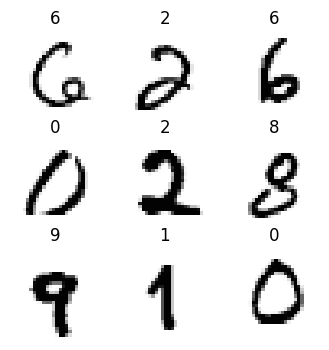

In [14]:
#| echo: false
#| output: true
#| eval: true
#| warning: false
# path_mnist.ls()
path= untar_data(URLs.MNIST)
def get_dls(bs=64):
  return DataBlock(
      blocks=(ImageBlock(cls=PILImageBW), CategoryBlock),
      get_items=get_image_files,
      splitter=GrandparentSplitter('training', 'testing'),
      get_y=parent_label,
      # item_tfms=Resize(28),
      batch_tfms=Normalize()
  ).dataloaders(path, bs=bs)
dls = get_dls()
# dls = dls.new(num_workers=0, persistent_workers=False)
# dls = dls.new(
#     num_workers=0, 
# )
dls.show_batch(max_n=9, figsize=(4,4))

In [17]:
def simple_cnn():
  return sequential(
    conv(1, 8, 5),   # Input: 28x28 -> Output: 14x14
    conv(8, 16),  # Input: 14x14 -> Output: 7x7
    conv(16, 32), # Input: 7x7 -> Output: 4x4
    conv(32, 64), # Input: 4x4 -> Output: 2x2
    conv(64, 10, act=False), # Input: 2x2 -> Output: 1x1
    Flatten()
)

In [18]:
def fit(epochs=1):
    learn = Learner(dls, simple_cnn(), loss_func=F.cross_entropy, metrics=accuracy, cbs=ActivationStats(with_hist=True))
    learn.fit(epochs, 0.06)

    return learn

learn = fit()

/home/ldinh/perso/perso/lib64/python3.11/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch,train_loss,valid_loss,accuracy,time
0,0.082206,0.043741,0.986261,00:04


### Use more activation functions
One simple tweak that we can apply to improve recognition accuracy is to use more activation functions in our `CNN`, as we need more `filters` to learn more complex patterns in 10-digit MNIST samples. To achieve this, we add one more activation function after each convolution layer in our `simple_cnn` architecture. As a result, the number of activations ends up being doubled.

However, adding more activation functions can lead to a subtle (training) problem. Specifically, when we apply 3x3-pixel kernel to the first convolution layer with 4 output filters, we embed information from 9 input pixels into 4 output pixels. While doubling the number of activation functions, we have the computation of 8 output pixels from 9 input pixels. It makes neural networks more difficult to learn the features while mapping from 9 input pixels to 8 output pixels than from 9 input pixels to 4 output pixels.

To deal with this issue, we can increase the kernel size from 3 to 5, which allows us to embed information from 25 input pixels into 8 output pixels. This makes it easier for the neural network to learn the features while mapping from 25 input pixels to 8 output pixels.


In [15]:
def simple_cnn():
  return sequential(
    conv(1, 8, 5),   # Input: 28x28 -> Output: 14x14
    conv(8, 16),  # Input: 14x14 -> Output: 7x7
    conv(16, 32), # Input: 7x7 -> Output: 4x4
    conv(32, 64), # Input: 4x4 -> Output: 2x2
    conv(64, 10, act=False), # Input: 2x2 -> Output: 1x1
    Flatten()
)

To train the model more quickly, we can set learning rate to 0.06 and use `ActivationStats` callback to monitor the activation statistics during training.

In [16]:
def fit(epochs=1):
    learn = Learner(dls, simple_cnn(), loss_func=F.cross_entropy, metrics=accuracy, cbs=ActivationStats(with_hist=True))
    learn.fit(epochs, 0.06)
    
    return learn

learn = fit()

/home/ldinh/perso/perso/lib64/python3.11/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")


epoch,train_loss,valid_loss,accuracy,time
0,2.307367,2.303929,0.113500,00:12


Surprisingly, the model is not trained at all, the accuracy is just around 10% (random guess). 
To findout what went wrong, we can plot the activation statistics of the first/penultimate convolution layers using `ActivationStats` callback. 
It shows that the activations of the first convolution layer are all zeros, and it carries over the next layer, meaning that the model is not learning anything.

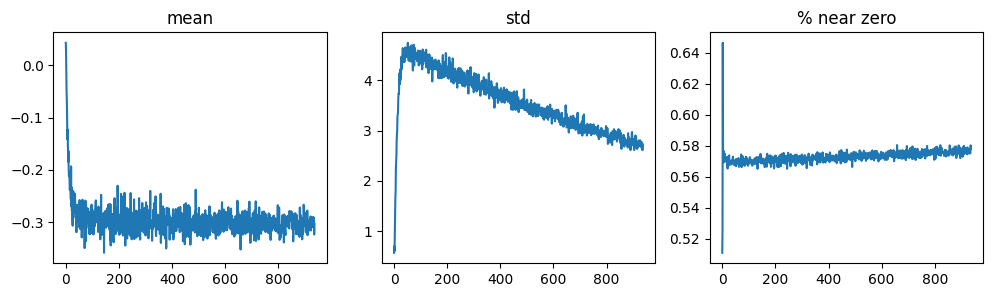

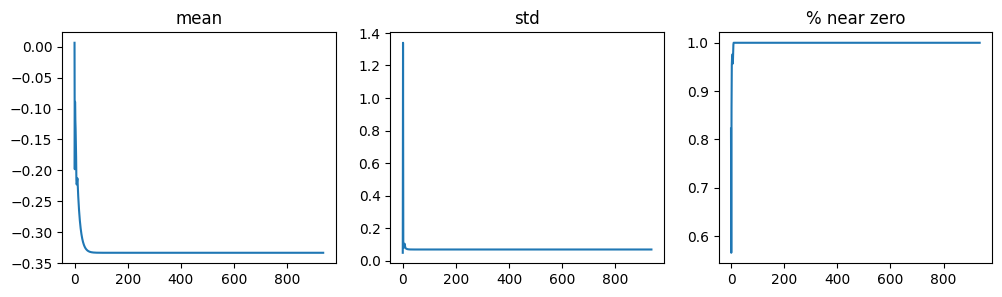

In [17]:
from fastai.callback.hook import *
# learn.recorder.plot_loss()
learn.activation_stats.plot_layer_stats(0)
learn.activation_stats.plot_layer_stats(-2)

To fix this issue, we can try several techniques to improve the training stability of our model.
### Increase Batch Size
To make training more stable, we can try to increase the batch size, because larger batch sizes prodive more accurate estimates of the gradients, which can help to reduce the noise in the training process. On the downside, larger batch sizes require more memory and less batches per epochs, which bring less opportunities for the model to update its weights, and also it is subject to hardware capabilities.

In [18]:
dls = get_dls(bs=512)
learn = fit()

epoch,train_loss,valid_loss,accuracy,time
0,0.375542,0.208636,0.931100,00:05


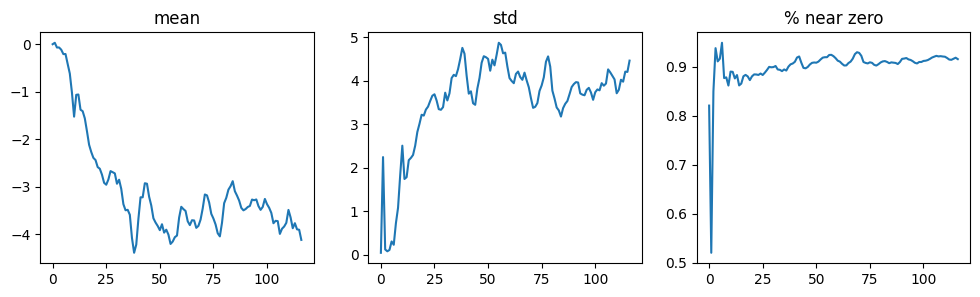

In [19]:
#| echo: false
learn.activation_stats.plot_layer_stats(-2)

Still, most of the activations are zeros, and the model is not learning anything when we change the batch size to 512 instead of 64.

### Learning Rate Finder

It is not favorable that we start training with a high learning rate for a bad initialization of weights. Also, we do not want to end training with a high learning rate either, because it can cause the model to overshoot the optimal weights. 

One way to deal with this issue has been proposed by Leslie Smith in his paper [Cyclical Learning Rates for Training Neural Networks](https://arxiv.org/abs/1708.07120) (Smith, 2017)^[Smith, L. (2017). "Cyclical Learning Rates for Training Neural Networks".]. The idea is to use a learning rate that varies cyclically between a lower and upper bound during training. This allows the model to:

- Explore different regions of the loss landscape and can help to avoid getting stuck in local minima (higher training rate helps to skip over small local minima).

- Improve generalization. Based on the fact that the training model with high learning rate tends to have diverging loss. If it is trained with that high learning rate for a while and it can find a good loss, it will find an area that generalizes well. Thus, a good strategy is to start with a low learning rate, where the loss does not diverge, and then allow optimizer to find smoother areas of parameters by going to higher learning rates. When the smoother areas are found, we can bring the learning rate down again to refine the weights. (i.e. `MomentumSGD` [A Disciplined Approach to Neural Network Hyper-Parameters: Part 1– LEARNING RATE, BATCH SIZE, MOMENTUM, AND WEIGHT DECAY](https://arxiv.org/pdf/1803.09820) (Smith, 2017)^[Smith, L. (2017). "A Disciplined Approach to Neural Network Hyper-Parameters: Part  1 LEARNING RATE, BATCH SIZE, MOMENTUM, AND WEIGHT DECAY .])


It is implemeted in `fastai` library as `fit_one_cycle` function.

In [20]:
def fit(epochs=1, lr=0.06):
    learn = Learner(dls, simple_cnn(), loss_func=F.cross_entropy, metrics=accuracy, cbs=ActivationStats(with_hist=True))
    learn.fit_one_cycle(epochs, lr)
    
    return learn

learn = fit()

epoch,train_loss,valid_loss,accuracy,time
0,0.209686,0.081768,0.973500,00:07


We can view the learning rate schedule and momentum during training by plotting the learning rate using `recorder.plot_sched` function.

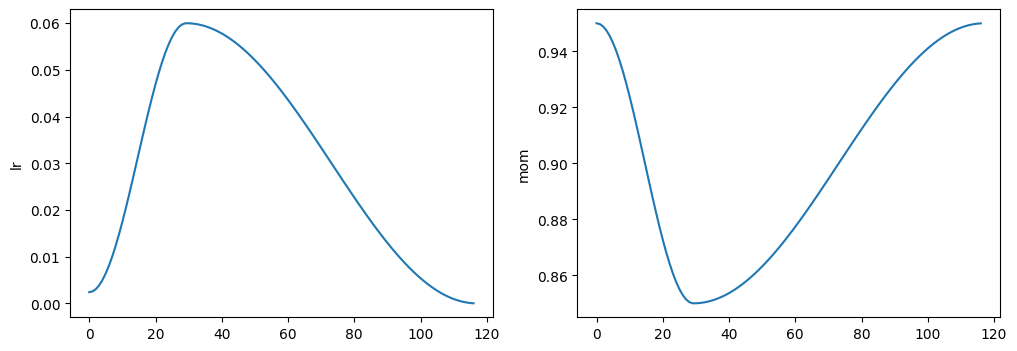

In [21]:
learn.recorder.plot_sched()

For `fit_one_cycle` function, there are several parameters that we can tune to improve the training stability and performance of our model, such as `lr_max`,`pct_start`, `div_factor`, and `final_div_factor`. For more details, see the [fastai documentation](https://docs.fast.ai/callback.schedule.html#fastai.callback.schedule.fit_one_cycle).


To see what is happening to the activations of the penultimate convolution layer, we can plot the activation statistics again. Now, the percentage of dead activations (all zeros) is significantly reduced, and the model is finally learning.

In [ ]:
#| echo: false
learn.activation_stats.plot_layer_stats(-2)

As we paid attention to the activation statistics during training, near-zero activations appear ar the beginning of training and gradually decreases as the training progresses. It suggests that the model training is not smooth because of the cylical learning rate going up and down during the cycle. 

To solve this problem, we can use batch normalization technique.

### Batch Normalization
As stated in [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/abs/1502.03167) (Sergey Ioffe)^[Sergey, Ioffe. (2015). "Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift.], they talked about the problem that we have seen earlier:

> "Training Deep Neural Networks is complicated by the fact that the distribution of each layer's inputs changes during training, as the parameters of the previous layers change. This slows down the training by requiring lower learning rates and careful parameter initialization, and makes it notoriously hard to train models with saturating nonlinearities."

To address this issue, they proposed a technique called **batch normalization**.

> "Making normalization a part of the model architecture and performing the normalization for each training mini-batch. Batch Normalization allows us to use much higher learning rates and be less careful about initialization." 


**Batch normalization** normalizes** the activations of each layer by averaging the means and standard deviations of the activations of a layer use those to normalize the activations. To further deal with situation when we need activation is high to make accurate prediction, they also introduced two learnable parameters per activation (i.e., $\gamma$ and $\beta$), which are used to scale and shift the normalized activations. After normalization, the activations get a vector $y$, and a batch normalization layer computes the output as follows: $\gamma*y + \beta$

By doing so, our activations can have any mean and standard deviation, which are independent from the previous layer. 

![Batch Normalization ](./imgs/batch_norm.png){#fig-bn fig-align="center"}

To add batch normalization to our `simple_cnn`, we can use `nn.BatchNorm2d` class from PyTorch. We can add a batch normalization layer after each convolution layer in our `simple_cnn` architecture as follows:

In [22]:
def conv(ni, nf, ks=3, act=True):
  layers = [nn.Conv2d(ni, nf, stride=2, kernel_size=ks, padding=ks//2)]
  layers.append(nn.BatchNorm2d(nf))
  if act: layers.append(nn.ReLU())
  return nn.Sequential(*layers)

In [23]:
#| echo: false
learn=fit()

epoch,train_loss,valid_loss,accuracy,time
0,0.128548,0.054535,0.986300,00:07


As a result, the accuracy is improved and the model is able to achieve around 98.6% accuracy on the MNIST dataset. Compared to the previous results, we observe that the model tends to generalize better with batch normalization. One possible reason is that batch normalization adds some noise to the activations during training, which can force the model learning more robust to these variations.

As some paper claimed that we should train with more epochs and larger learning rate when using batch normalization, we can try to train the model with 5 epochs and learning rate of 0.1.

In [24]:
#| echo: false
learn=fit(5, 0.1)

epoch,train_loss,valid_loss,accuracy,time
0,0.189483,0.148132,0.953000,00:07
1,0.081535,0.085481,0.974200,00:08
2,0.052703,0.077420,0.975900,00:08
3,0.030755,0.032069,0.989800,00:07
4,0.015828,0.024721,0.992200,00:08


Great, at this point, the model is able to achieve around 99.2% accuracy on the digit recognition task on MNIST dataset, which is a significant improvement compared to the previous results.

# Residual Networks (ResNet)
In the digit recognition task performed in MNIST dataset, we need to apply several convolution layers to reduce the spatial dimensions of the input image, which is 28x28 pixels, to a single output activation (using `Flatten()`). 

What would happen if we have a larger input image, for example, 128x128 or 224x224 pixels (`Imagenette` or `ImageNet` datasets)? We would need to apply more convolution layers to reduce the spatial dimensions of the input image to a single output activation. However, as we add more convolution layers, the model becomes more difficult to train. This is because the gradients become smaller as they are propagated back through the layers, which can lead to the problem of **vanishing gradients**.

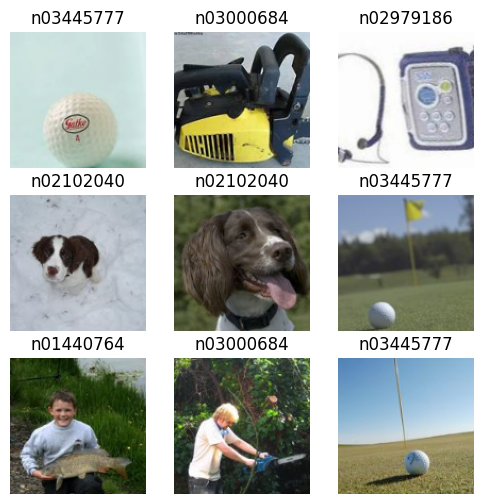

In [29]:
#| echo: false
#| output: false
#| eval: true
#| warning: false

dls = get_data(URLs.IMAGENETTE_160, 160, 128)
# dls = dls.new(num_workers=2, persistent_workers=False)
dls.show_batch(max_n=9, figsize=(6,6))

To address this issue, we can think of flattening the final convolution layer so that we can handle the grid size other than 1x1. For example, if the final convolution layer has a grid size of 2x2, we can flatten it to a vector of size 4 and then pass it to the final classification layer. However, this approach has several drawbacks: (1) it does not work with images of different sizes, (2) it requires more hardware resources as the number of activations fed to the final classification layer increases. This problem can be solved using **fully connected networks** to take the average of the activations across convolutional grid (it is implemented in `AdaptiveAvgPool2d` in PyTorch).


In [30]:
def block(ni ,nf): return ConvLayer(ni, nf, stride=2)
def get_model():
  return sequential(
    block(3, 16),   
    block(16, 32),  
    block(32, 64), 
    block(64, 128),
    block(128, 256),
    nn.AdaptiveAvgPool2d(1),
    Flatten(),
    nn.Linear(256, dls.c)
)

In the above `get_model` function, we create a CNN model with several convolution layers to reduce the spatial dimensions of the input image to a single output activation. We also use `AdaptiveAvgPool2d` to take the average of the activations across convolutional grid before passing it to the final classification layer.

Prior to training the model, we can use learning rate finder to find a good learning rate to start with. It appears that a learning rate of around 3e-3 is a good choice to start with.

In [31]:
def get_learner(model):
    learn = Learner(dls, model, loss_func=nn.CrossEntropyLoss(), metrics=accuracy, cbs=ActivationStats(with_hist=True)).to_fp16()
    
    return learn
learn = get_learner(get_model())

/home/ldinh/perso/perso/lib64/python3.11/site-packages/fastai/callback/core.py:71: UserWarning: You are shadowing an attribute (modules) that exists in the learner. Use `self.learn.modules` to avoid this
  warn(f"You are shadowing an attribute ({name}) that exists in the learner. Use `self.learn.{name}` to avoid this")
/home/ldinh/perso/perso/lib64/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/home/ldinh/perso/perso/lib64/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


SuggestedLRs(valley=0.015848932787775993)

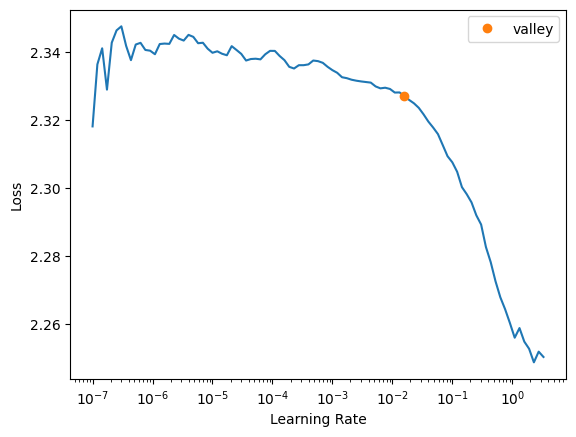

In [32]:
learn.lr_find()

In [33]:
#| echo: false
#| output: false
#| eval: true
#| warning: false

learn.fit_one_cycle(5, 3e-3)

/home/ldinh/perso/perso/lib64/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/home/ldinh/perso/perso/lib64/python3.11/site-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()


epoch,train_loss,valid_loss,accuracy,time
0,2.315616,2.296116,0.141911,00:36
1,2.261225,2.229563,0.213503,00:31
2,2.211662,2.194266,0.231338,00:31
3,2.184233,2.178069,0.235669,00:32
4,2.170955,2.176939,0.236943,00:30


It's a good start, when the model is able to achieve around 70% accuracy on the `Imagenette` dataset after 5 epochs of training. Let's try to stack more convolution layers to see if we can improve the accuracy further. 

In [ ]:
def get_model():
  return sequential(
    block(3, 16),   
    block(16, 32),  
    block(32, 64), 
    block(64, 128),
    block(128, 256),
    block(256, 512),
    block(512, 1024),
    nn.AdaptiveAvgPool2d(1),
    Flatten(),
    nn.Linear(1024, dls.c)
)
learn = get_learner(get_model())
learn.fit_one_cycle(5, 3e-3)

In [ ]:
def get_model():
  return sequential(
    block(3, 16),   
    block(16, 32),  
    block(32, 64), 
    block(64, 128),
    block(128, 256),
    block(256, 512),
    block(512, 1024),
    block(1024, 2056),
    block(2056, 4096),
    nn.AdaptiveAvgPool2d(1),
    Flatten(),
    nn.Linear(4096, dls.c)
)
learn = get_learner(get_model())
learn.fit_one_cycle(5, 3e-3)

In [ ]:
#| echo: false
def get_model():
  return sequential(
    block(3, 16),   
    block(16, 32),  
    block(32, 64), 
    block(64, 128),
    block(128, 256),
    nn.AdaptiveAvgPool2d(1),
    Flatten(),
    nn.Linear(256, dls.c)
)

As we can see, we can improve the accuracy of the model by stacking few more convolution layers. However, as we add more convolution layers, the performance of the model starts to degrade. To work around this issue, we can use **Residual Networks (ResNet)** architecture, which was proposed by Kaiming He et al. in their paper [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385) (He, 2015)^[He, K., Zhang, X., Ren, S., & Sun, J. (2015). "Deep Residual Learning for Image Recognition".]. As illustrated in the paper, adding more layers does not necessarily lead to better performance. 

> "Unexpectedly, such degradation is not caused by overfitting, and adding more layers to a suitably deep model leads to higher training error, as [previously reported] and thoroughly verified by our experiments."

![Training error w.r.t different layer depth from He et al. paper](./imgs/training_performance_layer.png){#fig-te fig-align="center"}

## Skip Connections in Residual Networks (ResNet)
The main idea behind ResNet is to use **skip connections** to allow the gradients to flow directly through the network, bypassing one or more layers as illustrated in @fig-resnet.

![An illustration of ResNet block](./imgs/resnet_block.png){#fig-resnet fig-align="center"}

::: {.callout-important}
## Key idea
The key idea of ResNet is to learn a **residual mapping**. Specifically, as the outcome of a given layer is $x$ and a ResNet block returns $y = x + block(x)$, instead of trying to predict the original mapping $block(x)$, which is **harder to learn**, the network learns the **residual** mapping, which minimizes the error between $x$ and $y$. It enables deeper networks to be trained effectively.
::: 

The code block below shows how to implement a ResNet block in PyTorch. We use `ConvLayer` from `fastai` library to create the convolution layers in the ResNet block. The first convolution layer has a ReLU activation function, while the second convolution layer uses batch normalization with zero initialization (`NormType.BatchZero`) to ensure that the initial state of the block is an **identity mapping**.

::: {.callout-important}
## Identity Mapping
By setting the weights of the second convolution layer's last batch normalization layer to zero, we ensure that the block output is initially equal to its input, i.e., $y = x + block(x) \approx x + 0 = x$. By doing so, we take the advantage of adding more layers without degrading the performance of the model (i.e., when deeper network does not bring any advantage, the network can set $y \approx x$ and does not yield any degradation).
:::


In [ ]:
def _conv_block(ni, nf, stride):
    return nn.Sequential(
        ConvLayer(ni, nf,  stride=stride),
        ConvLayer(nf, nf, act_cls=None, norm_type=NormType.BatchZero)
    )
class ResBlock(Module):
  def __init__(self, ni, nf, stride=1):
    self.convs = _conv_block(ni, nf, stride)
    self.idconv = noop if ni==nf else ConvLayer(ni, nf, 1, act_cls=None)
    self.pool = noop if stride==1 else nn.AvgPool2d(2, ceil_mode=True)

  def forward(self, x): return F.relu(self.convs(x) + self.idconv(self.pool(x)))

Now, lets create a deeper CNN model using ResNet blocks (twice deeper). We will use the same architecture as before, but we will replace the convolution layers with ResNet blocks.

In [ ]:
def block(ni ,nf): return nn.Sequential(ResBlock(ni, nf, stride=2), ResBlock(nf, nf))
learn = get_learner(get_model())
learn.fit_one_cycle(5, 3e-3)

## State-of-the-art ResNet
Coming from "Bags of Tricks for Image Classification with Convolutional Neural Networks" (He, 2019)^[He, K., Girshick, R., Dollár, P., & He, K. (2019). "Bags of Tricks for Image Classification with Convolutional Neural Networks".], the authors proposed several techniques to improve the performance of ResNet architecture, including tweaking ResNet-50 architecture and Mixup. 

Then, we can create a state-of-the-art ResNet model with the following tweaks:

- Use `stem` to enhance computational efficiency

- Use `Bottleneck Layer` in ResNet block to reduce the computational cost and time significantly

- Train with larger images (e.g., 224x224 pixels) and more epochs (e.g., 25 epochs)

- Use `Mixup` technique (data augmentation) to further improve the performance of the model.

### Stem
The difference compared to our previous ResNet architecture is that they used the **stem** of the network in the first layer, which consists of few convolution layers followed by a max pooling layer. The stem is considered instead of ResNet block because the vast majority of computatation is in the first few layers of the network, and using a stem can reduce the computational cost and time.

There are four ResNet blocks with 64, 128, 256, and 512 output filters, respectively. Each group starts with a stride-2 block, exept the first group, which is after the MaxPooing layer (`stem`).

In [ ]:
def _resnet_stem(*sizes):
  return [ConvLayer(sizes[i], sizes[i+1], stride=2 if i==0 else 1) for i in range(len(sizes)-1)] + [nn.MaxPool2d(3, stride=2, padding=1)]

In [ ]:
class ResNet(nn.Sequential):
  def __init__(self, n_out, layers, expansion=1):
    stem = _resnet_stem(3, 32, 32, 64)
    self.block_size = [64, 64, 128, 256, 512]
    for i in range(1,5):
      self.block_size[i] *= expansion
    blocks = [self._make_layer(*o) for o in enumerate(layers)]
    super().__init__(*stem, *blocks, nn.AdaptiveAvgPool2d(1), Flatten(), nn.Linear(self.block_size[-1], n_out))
  def _make_layer(self, i, n_layers):
    stride = 1 if i==0 else 2
    ch_in, ch_out = self.block_size[i:i+2]
    return nn.Sequential(*[ResBlock(ch_in if l==0 else ch_out, ch_out, stride if l==0 else 1) for l in range(n_layers)])

In [ ]:
rn = ResNet(dls.c, [2, 2, 2, 2], expansion=1)

In [ ]:
learn = get_learner(rn)
learn.fit_one_cycle(5, 3e-3)

### Bottleneck Layer

Another inmprovement we can apply is **Bottleneck Layer**. Instead of using two 3x3 convolution layers in the ResNet block, we can use a 1x1 convolution layer to reduce the number of filters, followed by a 3x3 convolution layer, and then another 1x1 convolution layer to increase the number of filters back. This reduces the computational cost and time significantly.

In [ ]:
def _conv_block(ni, nf, stride):
    return nn.Sequential(
        ConvLayer(ni, nf//4,  1),
        ConvLayer(nf//4, nf//4,  stride=stride),
        ConvLayer(nf//4, nf, 1, act_cls=None, norm_type=NormType.BatchZero)
    )

We can also create ResNet-50 architecture with 4 groups, of which the sizes are [3,4,6,3] and expansion factor of 4 (we need to start with 4 times fewer channels and end up 4 times more channels).

### Training with Larger Images and More Epochs
To really show the benefit of training deeper networks with bottleneck layers (i.e., higher parameters), we should consider more epochs of training (e.g., 20 epochs)
And lastly, we can perform ResNet-50 in a dataset with larger images (e.g., 224x224 pixels) to see how well it performs. In this case, we can try with resizing `Imagenette_320` dataset with 320x320 pixel images to 224-pixel image dataset.

In [ ]:
#| echo: false
dls = get_data(URLs.IMAGENETTE_320, 320, 224)
dls = dls.new(num_workers=0, persistent_workers=False)
# learn = get_learner(rn50)

In [ ]:
#| echo: false
rn50 = ResNet(dls.c, [3, 4, 6, 3], expansion=4)

In [ ]:
#| echo: false
learn = get_learner(rn50)

In [ ]:
#| echo: false
learn.fit_one_cycle(25, 3e-3)

The results that we have achieved is great with ResNet-50 model built from scratch (around 86% accuracy on `Imagenette` dataset with 224x224 pixel images after 25 epochs of training). 

### Mixup Technique
Finally, we can add `Mixup` technique to further improve the performance of our model. `Mixup` is a data augmentation technique that creates new training samples by mixing two random samples from the training set. This can help to improve the generalization of the model and reduce overfitting.
It is implemented in `fastai` library as `MixUp` callback.

In [ ]:
#| echo: false
def get_learner(model):
    learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=accuracy)
    learn.add_cb(MixUp(alpha=0.4))
    
    return learn
learn = get_learner(rn50) 
learn.fit_one_cycle(80, 3e-3)

# Conclusions
In this post, we have learned about convolutional neural networks (CNNs) and how they can be used for image classification tasks. We have also learned about several techniques to improve the training stability and performance of our model, including batch normalization, residual networks (ResNet), and Mixup. By applying these techniques, we were able to achieve state-of-the-art performance on the `Imagenette` dataset using a ResNet-50 architecture built from scratch.

## Technical Insights

::: {.callout-important}
## Key Technical Learnings
- Convolutional layers are the building blocks of CNNs, which are designed to process grid-like data such as images.
- Strides and padding are techniques used to control the spatial dimensions of the output feature map.
- Batch normalization is a technique used to improve the training stability and performance of deep neural networks by normalizing the activations of each layer.
- Residual networks (ResNet) are a type of CNN architecture that uses skip connections to allow the gradients to flow directly through the network, bypassing one or more layers.
- Mixup is a data augmentation technique that creates new training samples by mixing two random samples from the training set, which can help to improve the generalization of the model and reduce overfitting.
:::